# Final Weighted GRU

This is the main model notebook.

Split:
- train: 2010–2018
- validation: 2019–2021
- test: 2022–2026

Results are saved under `outputs/figures` and `outputs/metrics`.

In [7]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

from src.dataset import StockSequenceDataset, print_dataset_summary
from src.models import build_model, count_parameters

def rel_path(path):
    path = Path(path)
    try:
        return path.relative_to(PROJECT_ROOT).as_posix()
    except ValueError:
        return path.as_posix()

print("Setup complete.")
print("CUDA available:", torch.cuda.is_available())

Setup complete.
CUDA available: True


## Config

In [8]:
CSV_PATH = PROJECT_ROOT / "data" / "processed" / "features.csv"

TRAIN_END = "2018-12-31"
VAL_END = "2021-12-31"

MODEL_TYPE = "GRU"
EXPERIMENT_NAME = "gru_weighted"

LOOKBACK = 30
NUM_CLASSES = 3
LABEL_NAMES = ["down", "flat", "up"]

HIDDEN_DIM = 128
NUM_LAYERS = 1
DROPOUT = 0.3
BIDIRECTIONAL = False

BATCH_SIZE = 1024
LEARNING_RATE = 1e-3
EPOCHS = 8
WEIGHT_DECAY = 0.0
GRAD_CLIP_NORM = 1.0

MAX_TRAIN_SAMPLES = None
MAX_VAL_SAMPLES = None

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("CSV exists:", CSV_PATH.exists())
print("Model:", MODEL_TYPE)
print("Device:", DEVICE)

CSV exists: True
Model: GRU
Device: cuda


## Seed

In [9]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

## Load data

In [10]:
train_dataset = StockSequenceDataset(str(CSV_PATH), split="train", lookback=LOOKBACK, train_end=TRAIN_END, val_end=VAL_END)
val_dataset = StockSequenceDataset(str(CSV_PATH), split="val", lookback=LOOKBACK, train_end=TRAIN_END, val_end=VAL_END)
test_dataset = StockSequenceDataset(str(CSV_PATH), split="test", lookback=LOOKBACK, train_end=TRAIN_END, val_end=VAL_END)

print_dataset_summary(train_dataset, "Train Dataset")
print_dataset_summary(val_dataset, "Validation Dataset")
print_dataset_summary(test_dataset, "Test Dataset")

INPUT_DIM = train_dataset.X.shape[-1]
print("INPUT_DIM:", INPUT_DIM)

[train] Number of feature columns: 13
[train] Feature columns: ['daily_return', 'log_return', 'open_close_return', 'high_low_range', 'volume_change', 'ma_5_ratio', 'ma_10_ratio', 'ma_20_ratio', 'volatility_5', 'volatility_10', 'volatility_20', 'momentum_5', 'momentum_10']
[val] Number of feature columns: 13
[val] Feature columns: ['daily_return', 'log_return', 'open_close_return', 'high_low_range', 'volume_change', 'ma_5_ratio', 'ma_10_ratio', 'ma_20_ratio', 'volatility_5', 'volatility_10', 'volatility_20', 'momentum_5', 'momentum_10']
[test] Number of feature columns: 13
[test] Feature columns: ['daily_return', 'log_return', 'open_close_return', 'high_low_range', 'volume_change', 'ma_5_ratio', 'ma_10_ratio', 'ma_20_ratio', 'volatility_5', 'volatility_10', 'volatility_20', 'momentum_5', 'momentum_10']
Train Dataset
Number of samples: 1005533
X shape: (1005533, 30, 13)
y shape: (1005533,)
Target distribution:
  0: 312017 (31.03%)
  1: 283953 (28.24%)
  2: 409563 (40.73%)
Date range:
201

## DataLoaders

In [11]:
def maybe_subset(dataset, max_samples, seed=42):
    if max_samples is None or len(dataset) <= max_samples:
        return dataset
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(dataset), size=max_samples, replace=False)
    return Subset(dataset, np.sort(idx).tolist())

train_data = maybe_subset(train_dataset, MAX_TRAIN_SAMPLES, SEED)
val_data = maybe_subset(val_dataset, MAX_VAL_SAMPLES, SEED)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

print("Train samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Test samples:", len(test_dataset))

Train samples: 1005533
Validation samples: 368455
Test samples: 541680


## Build model

In [12]:
model = build_model(
    model_type=MODEL_TYPE,
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
    bidirectional=BIDIRECTIONAL,
).to(DEVICE)

class_counts = np.bincount(train_dataset.y, minlength=NUM_CLASSES)
class_weights = class_counts.sum() / (NUM_CLASSES * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print("Class counts:", class_counts)
print("Class weights:", class_weights)
print(model)
print("Trainable parameters:", count_parameters(model))

Class counts: [312017 283953 409563]
Class weights: [1.07422886 1.1803984  0.81837878]
RecurrentClassifier(
  (rnn): GRU(13, 128, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=128, out_features=3, bias=True)
  )
)
Trainable parameters: 55299


## Helper functions

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device, grad_clip_norm=None):
    model.train()
    total_loss = 0.0
    all_preds, all_targets = [], []

    for X, y in tqdm(loader, desc="Training", leave=False):
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()

        if grad_clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)

        optimizer.step()

        total_loss += loss.item() * X.size(0)
        all_preds.append(torch.argmax(logits, dim=1).detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)

    return (
        total_loss / len(loader.dataset),
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, average="macro"),
        f1_score(y_true, y_pred, average="weighted"),
    )


@torch.no_grad()
def evaluate_with_probs(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_targets, all_preds, all_probs = [], [], []

    for X, y in tqdm(loader, desc="Evaluating", leave=False):
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(X)
        loss = criterion(logits, y)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        total_loss += loss.item() * X.size(0)
        all_targets.append(y.detach().cpu().numpy())
        all_preds.append(preds.detach().cpu().numpy())
        all_probs.append(probs.detach().cpu().numpy())

    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    probs = np.concatenate(all_probs)

    return (
        total_loss / len(loader.dataset),
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, average="macro"),
        f1_score(y_true, y_pred, average="weighted"),
        y_true,
        y_pred,
        probs,
    )


def plot_confusion_matrix(cm, title, save_path, labels):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks(ticks=np.arange(len(labels)), labels=labels)
    plt.yticks(ticks=np.arange(len(labels)), labels=labels)
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

## Train

In [14]:
history = []
best_state = None
best_val_macro_f1 = -1.0
best_epoch = None

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_loss, train_acc, train_macro_f1, train_weighted_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE, GRAD_CLIP_NORM
    )

    val_loss, val_acc, val_macro_f1, val_weighted_f1, y_val_true, y_val_pred, val_probs = evaluate_with_probs(
        model, val_loader, criterion, DEVICE
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_macro_f1": train_macro_f1,
        "train_weighted_f1": train_weighted_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_macro_f1": val_macro_f1,
        "val_weighted_f1": val_weighted_f1,
    })

    print(f"train_loss={train_loss:.4f} | train_macro_f1={train_macro_f1:.4f}")
    print(f"val_loss={val_loss:.4f} | val_macro_f1={val_macro_f1:.4f}")

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

print(f"\nTraining time: {time.time() - start_time:.2f} seconds")
history_df = pd.DataFrame(history)
history_df


Epoch 1/8


Training:   0%|          | 0/982 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/360 [00:00<?, ?it/s]

train_loss=1.0820 | train_macro_f1=0.3676
val_loss=1.0752 | val_macro_f1=0.3657

Epoch 2/8


Training:   0%|          | 0/982 [00:00<?, ?it/s]

...

train_loss=1.0623 | train_macro_f1=0.4132
val_loss=1.0839 | val_macro_f1=0.3879

Epoch 8/8


Training:   0%|          | 0/982 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/360 [00:00<?, ?it/s]

train_loss=1.0585 | train_macro_f1=0.4187
val_loss=1.0827 | val_macro_f1=0.3935

Training time: 155.33 seconds


,epoch,train_loss,train_acc,train_macro_f1,train_weighted_f1,val_loss,val_acc,val_macro_f1,val_weighted_f1
0,1,1.082040,0.374241,0.367588,0.363038,1.075200,0.364908,0.365655,0.361588
1,2,1.078609,0.380690,0.374172,0.369069,1.076766,0.369364,0.368183,0.367711
2,3,1.076710,0.385707,0.380313,0.375913,1.080456,0.382929,0.377691,0.385318
3,4,1.073330,0.395026,0.391522,0.388319,1.080310,0.386566,0.381003,0.388438
4,5,1.069711,0.402525,0.400069,0.397811,1.080513,0.394040,0.386241,0.396472
5,6,1.066159,0.409127,0.406787,0.405970,1.079844,0.394797,0.383696,0.394720
6,7,1.062272,0.415344,0.413185,0.413219,1.083920,0.391416,0.387912,0.394330
7,8,1.058475,0.420728,0.418668,0.419387,1.082688,0.403672,0.393510,0.405835


## Training curves

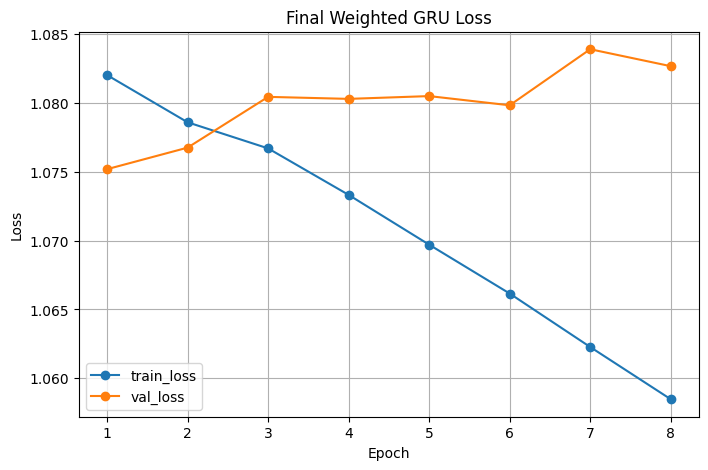

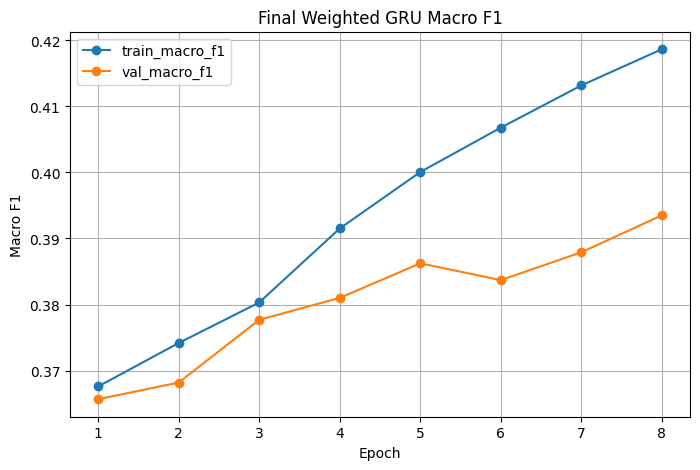

In [15]:
figures_dir = PROJECT_ROOT / "outputs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Weighted GRU Loss")
plt.legend()
plt.grid(True)
plt.savefig(figures_dir / "gru_weighted_loss.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_macro_f1"], marker="o", label="train_macro_f1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="val_macro_f1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Final Weighted GRU Macro F1")
plt.legend()
plt.grid(True)
plt.savefig(figures_dir / "gru_weighted_macro_f1.png", dpi=150, bbox_inches="tight")
plt.show()

## Validation and test reports

In [16]:
model.load_state_dict(best_state)
print("Best epoch:", best_epoch)
print("Best validation macro F1:", best_val_macro_f1)

val_loss, val_acc, val_macro_f1, val_weighted_f1, y_val_true, y_val_pred, val_probs = evaluate_with_probs(
    model, val_loader, criterion, DEVICE
)

test_loss, test_acc, test_macro_f1, test_weighted_f1, y_test_true, y_test_pred, test_probs = evaluate_with_probs(
    model, test_loader, criterion, DEVICE
)

print("\nValidation")
print("Loss:", val_loss)
print("Accuracy:", val_acc)
print("Macro F1:", val_macro_f1)
print("Weighted F1:", val_weighted_f1)
print(classification_report(y_val_true, y_val_pred, target_names=LABEL_NAMES, digits=4))

print("\nTest")
print("Loss:", test_loss)
print("Accuracy:", test_acc)
print("Macro F1:", test_macro_f1)
print("Weighted F1:", test_weighted_f1)
print(classification_report(y_test_true, y_test_pred, target_names=LABEL_NAMES, digits=4))

val_cm = confusion_matrix(y_val_true, y_val_pred)
test_cm = confusion_matrix(y_test_true, y_test_pred)

Best epoch: 8
Best validation macro F1: 0.3935095291405592


Evaluating:   0%|          | 0/360 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/529 [00:00<?, ?it/s]


Validation
Loss: 1.0826879063666686
Accuracy: 0.40367209021454453
Macro F1: 0.3935095291405592
Weighted F1: 0.40583464368189387
              precision    recall  f1-score   support

        down     0.3538    0.3870    0.3697    116598
        flat     0.3395    0.3598    0.3493     87428
          up     0.4867    0.4388    0.4615    164429

    accuracy                         0.4037    368455
   macro avg     0.3933    0.3952    0.3935    368455
weighted avg     0.4097    0.4037    0.4058    368455


Test
Loss: 1.091211144981559
Accuracy: 0.38971348397577904
Macro F1: 0.3685188736718252
Weighted F1: 0.38586042349427346
              precision    recall  f1-score   support

        down     0.3754    0.3607    0.3679    194942
        flat     0.3045    0.2563    0.2783    121382
          up     0.4348    0.4866    0.4593    225356

    accuracy                         0.3897    541680
   macro avg     0.3716    0.3679    0.3685    541680
weighted avg     0.3843    0.3897    0.385

## Save results

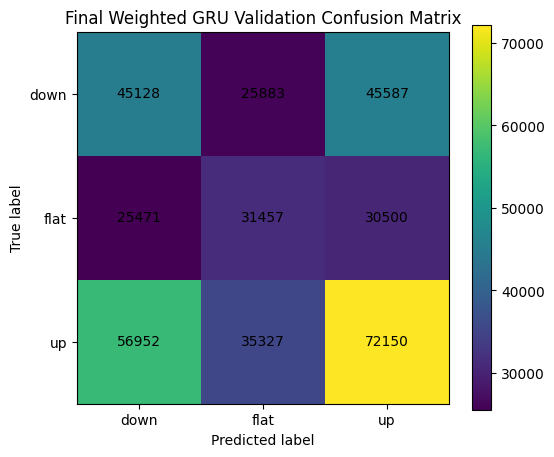

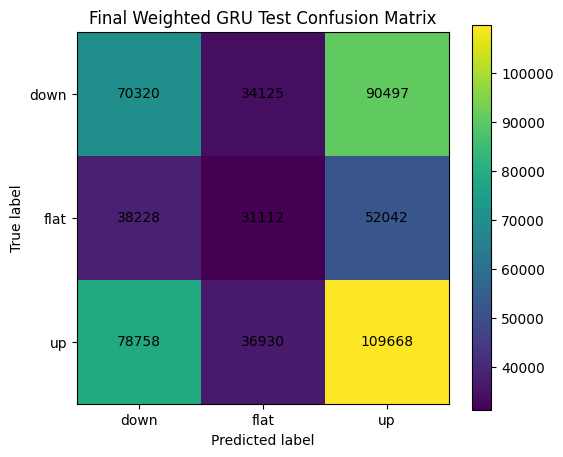

Saved: outputs/metrics/gru_weighted_summary.csv


,model,split,loss,accuracy,macro_f1,weighted_f1,down_f1,flat_f1,up_f1,best_epoch,input_dim,hidden_dim,num_layers,dropout,learning_rate
0,gru_weighted,validation,1.082688,0.403672,0.393510,0.405835,0.369676,0.349338,0.461515,8,13,128,1,0.3,0.001
1,gru_weighted,test,1.091211,0.389713,0.368519,0.385860,0.367929,0.278346,0.459282,8,13,128,1,0.3,0.001


In [17]:
metrics_dir = PROJECT_ROOT / "outputs" / "metrics"
figures_dir = PROJECT_ROOT / "outputs" / "figures"
metrics_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

plot_confusion_matrix(val_cm, "Final Weighted GRU Validation Confusion Matrix", figures_dir / "gru_weighted_val_confusion_matrix.png", LABEL_NAMES)
plot_confusion_matrix(test_cm, "Final Weighted GRU Test Confusion Matrix", figures_dir / "gru_weighted_test_confusion_matrix.png", LABEL_NAMES)

history_df.to_csv(metrics_dir / "gru_weighted_history.csv", index=False)

val_report = classification_report(y_val_true, y_val_pred, target_names=LABEL_NAMES, output_dict=True, digits=4)
test_report = classification_report(y_test_true, y_test_pred, target_names=LABEL_NAMES, output_dict=True, digits=4)

summary_df = pd.DataFrame([
    {
        "model": EXPERIMENT_NAME,
        "split": "validation",
        "loss": val_loss,
        "accuracy": val_acc,
        "macro_f1": val_macro_f1,
        "weighted_f1": val_weighted_f1,
        "down_f1": val_report["down"]["f1-score"],
        "flat_f1": val_report["flat"]["f1-score"],
        "up_f1": val_report["up"]["f1-score"],
        "best_epoch": best_epoch,
        "input_dim": INPUT_DIM,
        "hidden_dim": HIDDEN_DIM,
        "num_layers": NUM_LAYERS,
        "dropout": DROPOUT,
        "learning_rate": LEARNING_RATE,
    },
    {
        "model": EXPERIMENT_NAME,
        "split": "test",
        "loss": test_loss,
        "accuracy": test_acc,
        "macro_f1": test_macro_f1,
        "weighted_f1": test_weighted_f1,
        "down_f1": test_report["down"]["f1-score"],
        "flat_f1": test_report["flat"]["f1-score"],
        "up_f1": test_report["up"]["f1-score"],
        "best_epoch": best_epoch,
        "input_dim": INPUT_DIM,
        "hidden_dim": HIDDEN_DIM,
        "num_layers": NUM_LAYERS,
        "dropout": DROPOUT,
        "learning_rate": LEARNING_RATE,
    },
])

summary_path = metrics_dir / "gru_weighted_summary.csv"
summary_df.to_csv(summary_path, index=False)

if EXPERIMENT_NAME == "gru_weighted":
    summary_df.to_csv(metrics_dir / "gru_weighted_validation_vs_test.csv", index=False)

pd.DataFrame(val_cm, index=["true_down", "true_flat", "true_up"], columns=["pred_down", "pred_flat", "pred_up"]).to_csv(metrics_dir / "gru_weighted_val_confusion_matrix.csv")
pd.DataFrame(test_cm, index=["true_down", "true_flat", "true_up"], columns=["pred_down", "pred_flat", "pred_up"]).to_csv(metrics_dir / "gru_weighted_test_confusion_matrix.csv")

print("Saved:", rel_path(summary_path))
summary_df